In [1]:
import matplotlib.pyplot as plt
import o_voxel
import torch
import torch as th
import trimesh

In [37]:
RES = 2048

In [48]:
asset = trimesh.load("~/ns3/jaehyeok/ds/4d-gen/raw-glb/Truebone_Z-OO/Alligator/AlligatorALL-Bite5.glb")
asset.apply_scale(20.0)

# 1. Geometry Voxelization (Flexible Dual Grid)
# Returns: occupied indices, dual vertices (QEF solution), and edge intersected
mesh = asset.to_mesh()
vertices = torch.from_numpy(mesh.vertices).float()
faces = torch.from_numpy(mesh.faces).long()
voxel_indices, dual_vertices, intersected = o_voxel.convert.mesh_to_flexible_dual_grid(
    vertices,
    faces,
    grid_size=RES,  # Resolution
    aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],  # Axis-aligned bounding box
    face_weight=1.0,  # Face term weight in QEF
    boundary_weight=0.2,  # Boundary term weight in QEF
    regularization_weight=1e-2,  # Regularization term weight in QEF
    timing=True,
)
## sort to ensure align between geometry and material voxelization
vid = o_voxel.serialize.encode_seq(voxel_indices)
mapping = torch.argsort(vid)
voxel_indices = voxel_indices[mapping]
dual_vertices = dual_vertices[mapping]
intersected = intersected[mapping]

# 2. Material Voxelization (Volumetric Attributes)
# Returns: dict containing 'base_color', 'metallic', 'roughness', etc.
voxel_indices_mat, attributes = o_voxel.convert.textured_mesh_to_volumetric_attr(
    asset, grid_size=RES, aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]], timing=True
)
## sort to ensure align between geometry and material voxelization
vid_mat = o_voxel.serialize.encode_seq(voxel_indices_mat)
mapping_mat = torch.argsort(vid_mat)
attributes = {k: v[mapping_mat] for k, v in attributes.items()}

# Save to compressed .vxz format
## packing
dual_vertices = dual_vertices * RES - voxel_indices
dual_vertices = (torch.clamp(dual_vertices, 0, 1) * 255).type(torch.uint8)
intersected = (intersected[:, 0:1] + 2 * intersected[:, 1:2] + 4 * intersected[:, 2:3]).type(torch.uint8)
attributes["dual_vertices"] = dual_vertices
attributes["intersected"] = intersected
o_voxel.io.write("ovoxel_helmet.vxz", voxel_indices, attributes)
# o_voxel.io.write("ovoxel_helmet.ply", voxel_indices, attributes)

Intersect QEF computation took 0.012451 seconds.
Face QEF computation took 0.007073 seconds.
Boundary QEF computation took 0.002172 seconds.
Dual vertices computation took 0.030928 seconds.
Mipmaps construction took 0.018012 seconds.
Voxelization took 0.113935 seconds.
Normalization took 0.00085 seconds.


In [49]:
dual_vertices.shape

torch.Size([110850, 3])

In [50]:
import torch
import o_voxel
import numpy as np


def export_ovoxel_to_glb(
    # Geometry Inputs
    voxel_indices,  # (N, 3) Int Tensor
    dual_vertices,  # (N, 3) Float or Uint8 Tensor
    intersected,  # (N, 3) Bool or (N, 1) Packed Uint8 Tensor
    # Material Inputs
    voxel_indices_mat,  # (M, 3) Int Tensor
    attributes,  # Dict of (M, C) Tensors
    # Settings
    res=512,
    filename="rec_helmet.glb",
):
    print(f"--- Starting Export: {filename} ---")
    device = torch.device("cuda")

    # -------------------------------------------------
    # 1. Prepare Geometry Data
    # -------------------------------------------------
    coords = voxel_indices.to(device)

    # Handle Dual Vertices (Normalize if uint8 0-255, else keep as is)
    d_verts = dual_vertices.to(device).float()
    if d_verts.max() > 1.0:
        d_verts = d_verts / 255.0

    # Handle Intersected Flags (Unpack bits if packed, else ensure bool)
    intersect_flags = intersected.to(device)
    if intersect_flags.shape[-1] == 1 or intersect_flags.ndim == 1:
        # Packed format (0-7 integer), unpack to (N, 3) boolean
        # Logic from official example:
        intersect_flags = intersect_flags.long().squeeze()
        intersect_flags = torch.stack(
            [
                (intersect_flags % 2).bool(),  # Bit 0: X
                (intersect_flags // 2 % 2).bool(),  # Bit 1: Y
                (intersect_flags // 4 % 2).bool(),  # Bit 2: Z
            ],
            dim=-1,
        )
    else:
        # Already (N, 3), ensure bool
        intersect_flags = intersect_flags.bool()

    # -------------------------------------------------
    # 2. Align & Pack Attributes
    # -------------------------------------------------
    print("Aligning material attributes to geometry...")

    # Keys we want to export
    target_keys = ["base_color", "metallic", "roughness", "opacity", "alpha"]

    # Prepare alignment mapping
    geo_keys = o_voxel.serialize.encode_seq(coords)
    mat_keys = o_voxel.serialize.encode_seq(voxel_indices_mat.to(device))

    mat_keys_sorted, mat_perm = torch.sort(mat_keys)
    search_idx = torch.searchsorted(mat_keys_sorted, geo_keys)
    search_idx = torch.clamp(search_idx, 0, len(mat_keys_sorted) - 1)
    valid_mask = mat_keys_sorted[search_idx] == geo_keys

    matched_indices = mat_perm[search_idx[valid_mask]]

    # Build the concatenated volume
    tensors_to_stack = []
    attr_layout = {}
    current_idx = 0

    for key in target_keys:
        if key in attributes:
            # Get raw data (M, C)
            raw_val = attributes[key].to(device).float()
            if raw_val.ndim == 1:
                raw_val = raw_val.unsqueeze(1)

            # Normalize 0-255 -> 0-1
            if raw_val.max() > 1.0:
                raw_val /= 255.0

            # Create aligned container (N, C) filled with defaults
            aligned_val = torch.zeros((coords.shape[0], raw_val.shape[1]), device=device)

            # Set default roughness to 0.5 instead of 0.0 if missing
            if key == "roughness":
                aligned_val[:] = 0.5
            # Set default opacity to 1.0 instead of 0.0 if missing
            if key == "opacity":
                aligned_val[:] = 1.0

            # Copy matched data
            aligned_val[valid_mask] = raw_val[matched_indices]

            tensors_to_stack.append(aligned_val)

            # Define layout
            num_channels = raw_val.shape[1]
            attr_layout[key] = slice(current_idx, current_idx + num_channels)

            # Helper for 'alpha' alias
            if key == "opacity":
                attr_layout["alpha"] = attr_layout["opacity"]

            current_idx += num_channels

    attr_volume = torch.cat(tensors_to_stack, dim=1)

    # -------------------------------------------------
    # 3. Reconstruct Mesh
    # -------------------------------------------------
    print("Reconstructing mesh from dual grid...")
    rec_verts, rec_faces = o_voxel.convert.flexible_dual_grid_to_mesh(
        coords=coords,
        dual_vertices=d_verts,
        intersected_flag=intersect_flags,
        split_weight=None,
        grid_size=res,
        aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
    )

    # -------------------------------------------------
    # 4. Post-process & Export
    # -------------------------------------------------
    print("Baking textures and exporting GLB...")
    mesh = o_voxel.postprocess.to_glb(
        vertices=rec_verts,
        faces=rec_faces,
        attr_volume=attr_volume,
        coords=coords,
        attr_layout=attr_layout,
        grid_size=res,
        aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
        decimation_target=100000,
        texture_size=2048,
        verbose=True,
    )

    mesh.export(filename)
    print(f"Success! Saved to {filename}")


# ==========================================================
# USAGE
# ==========================================================
# Run this using the variables currently in your memory:

export_ovoxel_to_glb(
    voxel_indices=voxel_indices,
    dual_vertices=dual_vertices,
    intersected=intersected,
    voxel_indices_mat=voxel_indices_mat,
    attributes=attributes,
    res=RES,
    filename="final_alligator.glb",
)

--- Starting Export: final_alligator.glb ---
Aligning material attributes to geometry...
Reconstructing mesh from dual grid...
Baking textures and exporting GLB...
Original mesh: 110850 vertices, 223388 faces
After filling holes: 110852 vertices, 223396 faces
Building BVH for current mesh...

Done
Cleaning mesh...
After inital simplification: 110852 vertices, 223396 faces
After initial cleanup: 114522 vertices, 225858 faces


Simplifying [thres=1.00e-07]: 100%|██████████| 125858/125858 [00:00<00:00, 4389472.26it/s]

After final simplification: 49950 vertices, 97606 faces
After final cleanup: 49784 vertices, 97583 faces
Done
Parameterizing new mesh...


Get 413 clusters after fast clustering


Gathering results from xatlas: 100%|██████████| 413/413 [00:00<00:00, 23357.30it/s]


Done
Sampling attributes...Done
Finalizing mesh...Done
Success! Saved to final_alligator.glb


In [51]:
import imageio
import numpy as np
import o_voxel
import torch


# ---------------------------------------------------------
# 1. Camera Helper Functions
# ---------------------------------------------------------
def get_look_at(eye, target, up):
    # Ensure inputs are float32
    eye = torch.tensor(eye, device="cuda", dtype=torch.float32)
    target = torch.tensor(target, device="cuda", dtype=torch.float32)
    up = torch.tensor(up, device="cuda", dtype=torch.float32)

    z_axis = eye - target
    z_axis = z_axis / torch.norm(z_axis)

    x_axis = torch.cross(up, z_axis)
    x_axis = x_axis / torch.norm(x_axis)

    y_axis = torch.cross(z_axis, x_axis)
    y_axis = y_axis / torch.norm(y_axis)

    # World-to-Camera
    R = torch.stack([x_axis, y_axis, z_axis])
    t = -torch.matmul(R, eye)

    extr = torch.eye(4, device="cuda")
    extr[:3, :3] = R
    extr[:3, 3] = t

    # FIX: Return (4, 4) unbatched
    return extr


def get_intrinsics(fov_degrees, H, W):
    f_y = 0.5 * H / np.tan(np.deg2rad(fov_degrees) / 2)
    f_x = f_y  # Square pixels

    intr = torch.tensor([[f_x, 0.0, W / 2], [0.0, f_y, H / 2], [0.0, 0.0, 1.0]], device="cuda", dtype=torch.float32)

    # FIX: Return (3, 3) unbatched
    return intr


# ---------------------------------------------------------
# 2. Prepare Data (Reuse your variables)
# ---------------------------------------------------------
device = torch.device("cuda")
RES = 512

# A. Geometry Coordinates (Normalized to -0.5 ~ 0.5)
coords = voxel_indices.to(device)
position = (coords.float() / RES) - 0.5

# B. Align Attributes
geo_keys = o_voxel.serialize.encode_seq(coords)
mat_keys = o_voxel.serialize.encode_seq(voxel_indices_mat.to(device))
mat_keys_sorted, mat_perm = torch.sort(mat_keys)

search_idx = torch.searchsorted(mat_keys_sorted, geo_keys)
search_idx = torch.clamp(search_idx, 0, len(mat_keys_sorted) - 1)
valid_mask = mat_keys_sorted[search_idx] == geo_keys
matched_indices = mat_perm[search_idx[valid_mask]]

# Prepare Base Color
final_colors = torch.full((coords.shape[0], 3), 0.5, device=device)  # Default gray

if "base_color" in attributes:
    raw_color = attributes["base_color"].to(device).float()
    if raw_color.max() > 1.0:
        raw_color /= 255.0
    final_colors[valid_mask] = raw_color[matched_indices]

# ---------------------------------------------------------
# 3. Render
# ---------------------------------------------------------
print("Rendering...")

# Setup Camera (Unbatched)
extr = get_look_at(eye=[1.2, 0.8, 1.2], target=[0.0, 0.0, 0.0], up=[0.0, 1.0, 0.0])
intr = get_intrinsics(fov_degrees=45.0, H=512, W=512)

# Initialize Renderer
renderer = o_voxel.rasterize.VoxelRenderer(rendering_options={"resolution": 512, "ssaa": 2})

# Run
output = renderer.render(
    position=position,  # (N, 3)
    attrs=final_colors,  # (N, 3)
    voxel_size=1.0 / RES,
    extrinsics=extr,  # (4, 4)
    intrinsics=intr,  # (3, 3)
)

# ---------------------------------------------------------
# 4. Save Image
# ---------------------------------------------------------
# Since inputs were unbatched, output.attr is likely (C, H, W)
out_tensor = output.attr
if out_tensor.dim() == 4:  # Handle case if it returns (1, C, H, W)
    out_tensor = out_tensor[0]

image = out_tensor.permute(1, 2, 0).detach().cpu().numpy()
image = np.clip(image * 255, 0, 255).astype(np.uint8)

imageio.imwrite("alligator_viz.png", image)
print("Saved visualization to alligator_viz.png")

Rendering...
Saved visualization to alligator_viz.png


In [47]:
intr

tensor([[618.0387,   0.0000, 256.0000],
        [  0.0000, 618.0387, 256.0000],
        [  0.0000,   0.0000,   1.0000]], device='cuda:0')

In [ ]:
import utils3d

In [79]:
extr = utils3d.extrinsics_look_at(
    eye=torch.tensor([1.2, 0.5, 1.2]), look_at=torch.tensor([0.0, 0.0, 0.0]), up=torch.tensor([0.0, 1.0, 0.0])
).cuda()
intr = utils3d.intrinsics_from_fov_xy(
    fov_x=torch.deg2rad(torch.tensor(45.0)),
    fov_y=torch.deg2rad(torch.tensor(45.0)),
).cuda()

In [85]:
# Load data
coords, data = o_voxel.io.read("ovoxel_helmet.vxz")
position = (coords / RES - 0.5).cuda()
base_color = (data["base_color"] / 255).cuda()

# Render
renderer = o_voxel.rasterize.VoxelRenderer(rendering_options={"resolution": 512, "ssaa": 2})
output = renderer.render(
    position=position,  # Voxel centers
    attrs=base_color,  # Color/Opacity etc.
    voxel_size=1.0 / RES,
    extrinsics=extr,
    intrinsics=intr,
)
# output.attr contains the rendered image (C, H, W)

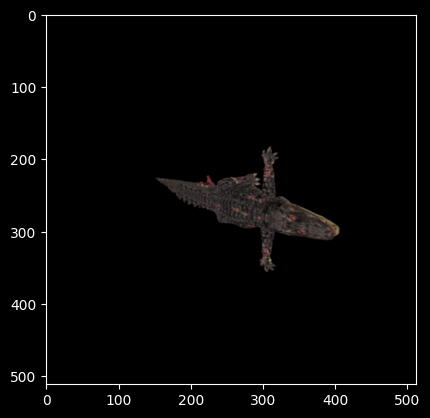

In [86]:
plt.imshow((output.attr.permute(1, 2, 0) * 255 + 0.5).to("cpu", th.uint8).numpy())